# Daymet Data Download and Conifer Masking (Vectorized)
This notebook downloads Daymet data from the Microsoft Planetary Computer, clips it to California, and efficiently masks it to a conifer grid using a vectorized boolean mask.

In [ ]:
# Environment setup helper (safe in Python kernel)
# Installs required packages if missing using pip via subprocess.

import sys
import subprocess

# Keep dependencies lightweight to avoid native builds (GDAL/PROJ)
# We intentionally skip geopandas/pyproj/rioxarray here, EXCEPT we add pyproj for CRS transforms.
pkgs = [
    "fsspec",
    "numpy",
    "xarray[complete]",  # ensure IO/backends incl. zarr plugin
    "zarr",  # xarray zarr engine
    "shapely",
    "pandas",
    "pystac",
    "tqdm",
    "pyshp",  # pure-Python shapefile reader
    "requests",
    "aiohttp",
    "planetary-computer",
    "matplotlib",
    "scipy"
]

def ensure(pkg):
    try:
        __import__(pkg.split("[",1)[0].replace("-","_"))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in pkgs:
    ensure(p)

print("Environment ready (xarray[complete] + zarr + pyproj installed).")


Environment ready (xarray[complete] + zarr + pyproj installed).


In [ ]:
# Minimal setup + path resolution
import os, sys, ssl, warnings
import numpy as np
import xarray as xr
import fsspec
import shapefile
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import planetary_computer as pc
import rasterio

# Guard against double patching aiohttp (prevent recursion)
import aiohttp, aiohttp.connector
TCP = aiohttp.connector.TCPConnector
if not getattr(TCP, "_ssl_patched", False):
    if not hasattr(TCP, "_orig_init"):
        TCP._orig_init = TCP.__init__
    def _patched(self, *args, **kwargs):
        if "ssl" not in kwargs:
            kwargs["ssl"] = False
        return TCP._orig_init(self, *args, **kwargs)
    TCP.__init__ = _patched
    TCP._ssl_patched = True

# Disable SSL verification globally
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context
os.environ.update({
    "PYTHONHTTPSVERIFY": "0",
    "SSL_VERIFY": "0",
    "CURL_CA_BUNDLE": "",
    "REQUESTS_CA_BUNDLE": "",
})

default_root = os.path.abspath(os.path.join(os.path.expanduser("~"), "Downloads", "Capstone", "Capstone"))
workspace_root = os.getcwd()
if ".Trash" in workspace_root or not os.path.isdir(os.path.join(workspace_root, "data")):
    workspace_root = default_root

RAW_DIR = os.path.join(workspace_root, "data", "raw_data")
CA_STATE_DIR = os.path.join(RAW_DIR, "ca_state")
OUTPUT_DIR = RAW_DIR
ca_shp = os.path.join(CA_STATE_DIR, "CA_State.shp")
print("Workspace:", workspace_root)
print("Shapefile:", ca_shp)
if not os.path.exists(ca_shp):
    raise FileNotFoundError(f"Shapefile not found at {ca_shp}. Ensure CA_State.shp/shx/dbf present.")
print("Setup complete.")

Workspace: /Users/macbook/Downloads/Capstone/Capstone
Shapefile: /Users/macbook/Downloads/Capstone/Capstone/data/raw_data/ca_state/CA_State.shp
Setup complete.


Loading California boundary for mask preview...
CA polygon type (native): MultiPolygon
CA polygon bounds (native): (-13857274.729899999, 3832930.6171000004, -12705029.5695, 5162405.9406)
Detected projected Web Mercator; converting polygon to WGS84 lon/lat...
CA polygon type (WGS84): MultiPolygon
CA polygon bounds (WGS84): (-124.48201686112382, 32.528836736912396, -114.13122247472315, 42.009522269621094)
Opening Daymet coords for mask preview...
Daymet grid shape: 8075x7814
Lat min/max: 6.08138370513916 83.79330444335938
Lon min/max: -179.99989318847656 179.9999237060547
Sample (2018,1953) → lon/lat=(-152.593,62.069) inside CA? False
Sample (4037,3907) → lon/lat=(-109.702,51.052) inside CA? False
Sample (6056,5860) → lon/lat=(-85.890,31.411) inside CA? False
Mask preview (WGS84): 390614 pixels inside CA


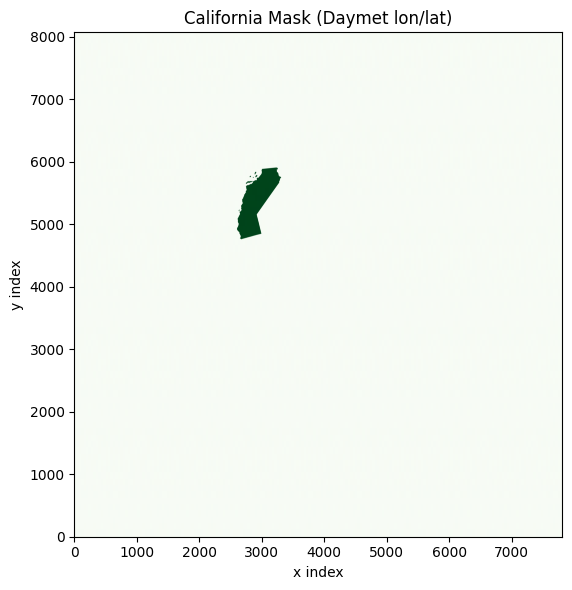

In [ ]:
# Verify and visualize CA mask without pyproj by converting Web Mercator → WGS84 manually
import os
import numpy as np
import fsspec
import planetary_computer as pc
import shapefile
from shapely.geometry import Polygon, Point, MultiPolygon
from shapely.ops import unary_union
from shapely.prepared import prep
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import xarray as xr
import math

# Use directories resolved in setup
try:
    shp_dir = CA_STATE_DIR
except NameError:
    raise RuntimeError("Setup cell not run. Please run Cell 1 and Cell 2 first.")

# Load California polygon (native coords)
def load_ca_polygon_raw(shp_dir: str):
    shp_file = os.path.join(shp_dir, "CA_State.shp")
    sf = shapefile.Reader(shp_file)
    polys = []
    for sh in sf.shapes():
        pts = sh.points
        parts = list(sh.parts) + [len(pts)]
        for i in range(len(parts) - 1):
            ring = pts[parts[i]:parts[i + 1]]
            if len(ring) >= 3:
                polys.append(Polygon(ring))
    # Return union, may be MultiPolygon
    merged = unary_union(polys)
    return merged

print("Loading California boundary for mask preview...")
ca_poly_native = load_ca_polygon_raw(shp_dir)
print("CA polygon type (native):", type(ca_poly_native).__name__)
print("CA polygon bounds (native):", ca_poly_native.bounds)

# Detect CRS from .prj (expect Web Mercator) and convert polygon to WGS84 lon/lat without pyproj
prj_path = os.path.join(shp_dir, "CA_State.prj")
crs_wkt = None
if os.path.exists(prj_path):
    with open(prj_path, "r") as f:
        crs_wkt = f.read().strip()
else:
    print("No .prj found; assuming WGS84 lon/lat.")

R = 6378137.0

def webmerc_to_lonlat(x, y):
    lon = (x / R) * (180.0 / math.pi)
    lat = (2.0 * math.atan(math.exp(y / R)) - (math.pi / 2.0)) * (180.0 / math.pi)
    return lon, lat

def transform_polygon_webmerc_to_wgs84(poly):
    def transform_single(p: Polygon) -> Polygon:
        xs, ys = p.exterior.coords.xy
        lonlat = [webmerc_to_lonlat(float(xs[k]), float(ys[k])) for k in range(len(xs))]
        return Polygon(lonlat)
    if isinstance(poly, Polygon):
        return transform_single(poly)
    elif isinstance(poly, MultiPolygon):
        parts = [transform_single(p) for p in poly.geoms]
        return unary_union(parts)
    else:
        # Fallback: try to construct from exterior if available
        try:
            return transform_single(Polygon(poly.exterior.coords))
        except Exception:
            raise TypeError("Unsupported geometry type for transformation: " + type(poly).__name__)

if crs_wkt and ("Mercator" in crs_wkt or "Web_Mercator" in crs_wkt or "UNIT[\"Meter\"" in crs_wkt):
    print("Detected projected Web Mercator; converting polygon to WGS84 lon/lat...")
    ca_poly = transform_polygon_webmerc_to_wgs84(ca_poly_native)
else:
    print("Treating polygon as WGS84 lon/lat.")
    ca_poly = ca_poly_native

prepared_poly = prep(ca_poly)
print("CA polygon type (WGS84):", type(ca_poly).__name__)
print("CA polygon bounds (WGS84):", ca_poly.bounds)

# Open Daymet coords via ABFS with SAS
base_https = "https://daymeteuwest.blob.core.windows.net/daymet-zarr/monthly/na.zarr"
signed = pc.sign(base_https)
parsed = urlparse(signed)
sas_token = parsed.query
fs = fsspec.filesystem(
    "abfs",
    account_name="daymeteuwest",
    endpoint="blob.core.windows.net",
    sas_token=sas_token,
)
store = fs.get_mapper("daymet-zarr/monthly/na.zarr")
print("Opening Daymet coords for mask preview...")
ds_coords = xr.open_zarr(store, consolidated=True)
lat = ds_coords["lat"].values
lon = ds_coords["lon"].values
Y, X = lat.shape
print(f"Daymet grid shape: {Y}x{X}")
print("Lat min/max:", float(np.nanmin(lat)), float(np.nanmax(lat)))
print("Lon min/max:", float(np.nanmin(lon)), float(np.nanmax(lon)))

# Normalize longitude if in 0..360
if np.nanmax(lon) > 180:
    lon = np.where(lon > 180, lon - 360.0, lon)
    print("Converted longitudes from 0..360 to -180..180.")

# Diagnostic sample checks
sample_idxs = [(int(Y*0.25), int(X*0.25)), (int(Y*0.5), int(X*0.5)), (int(Y*0.75), int(X*0.75))]
for i, j in sample_idxs:
    pt = Point(float(lon[i, j]), float(lat[i, j]))
    print(f"Sample ({i},{j}) → lon/lat=({float(lon[i,j]):.3f},{float(lat[i,j]):.3f}) inside CA?", prepared_poly.contains(pt) or prepared_poly.intersects(pt))

# Build mask in lon/lat
mask = np.zeros((Y, X), dtype=bool)
for i in range(Y):
    for j in range(X):
        mask[i, j] = prepared_poly.contains(Point(float(lon[i, j]), float(lat[i, j]))) or prepared_poly.intersects(Point(float(lon[i, j]), float(lat[i, j])))

inside = int(mask.sum())
print("Mask preview (WGS84):", inside, "pixels inside CA")

# Visualize mask
plt.figure(figsize=(7, 6))
plt.imshow(mask, origin='upper', cmap='Greens')
plt.title('California Mask (Daymet lon/lat)')
plt.xlabel('x index')
plt.ylabel('y index')
plt.tight_layout()
plt.show()

CA_MASK_PREVIEW = mask

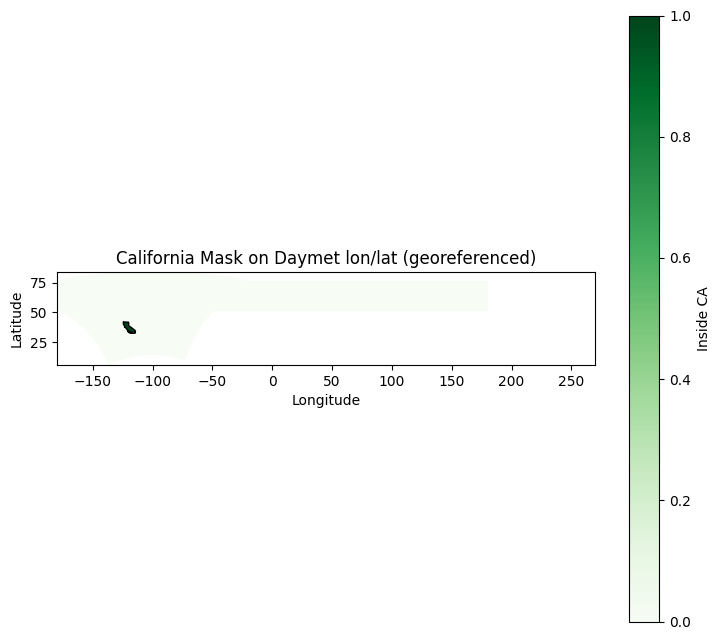

In [ ]:
# Improved visualization: georeferenced plot using pcolormesh + polygon outline
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

# Require lon/lat and ca_poly from Cell 3 context
try:
    lon
    lat
    ca_poly
    mask
except NameError:
    raise RuntimeError("Run Cells 2–3 first to load lon/lat, polygon, and mask.")

plt.figure(figsize=(7.5, 6.5))
# pcolormesh places cells by lon/lat, avoiding orientation artifacts
plt.pcolormesh(lon, lat, mask, shading='auto', cmap='Greens')
plt.colorbar(label='Inside CA')

# Overlay polygon outline in lon/lat space
def draw_poly(geom, **kw):
    if isinstance(geom, Polygon):
        xs, ys = geom.exterior.xy
        plt.plot(xs, ys, **kw)
    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            xs, ys = g.exterior.xy
            plt.plot(xs, ys, **kw)

draw_poly(ca_poly, color='k', linewidth=1.0)
plt.title('California Mask on Daymet lon/lat (georeferenced)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [ ]:
# Daymet monthly → CA mask → NetCDF (2000–2020) via ABFS (consolidated)
import os
import numpy as np
import xarray as xr
import fsspec
import planetary_computer as pc
import shapefile
from shapely.geometry import Polygon, Point, MultiPolygon
from shapely.ops import unary_union
from shapely.prepared import prep
from urllib.parse import urlparse
from matplotlib.path import Path

# Use directories resolved in the setup cell
try:
    OUTPUT_DIR = RAW_DIR
    shp_dir = CA_STATE_DIR
except NameError:
    raise RuntimeError("Setup cell not run. Please run Cell 1 and Cell 2 first.")

YEARS = list(range(2000, 2021))
VARS = ["prcp", "tmin", "tmax", "vp"]
ALIAS_MAP = {"prcp": "prcp", "tmin": "minat", "tmax": "maxat", "vp": "wvp"}

# Validate shapefile exists at resolved path
shp_file = os.path.join(shp_dir, "CA_State.shp")
if not os.path.exists(shp_file):
    raise FileNotFoundError(f"Shapefile missing at {shp_file}. Ensure CA_State.shp/shx/dbf present.")

# Load California polygon (WGS84 expected if you ran Cell 3 to preview mask)
def load_ca_polygon(shp_dir: str):
    sf = shapefile.Reader(os.path.join(shp_dir, "CA_State.shp"))
    polys = []
    for sh in sf.shapes():
        pts = sh.points
        parts = list(sh.parts) + [len(pts)]
        for i in range(len(parts) - 1):
            ring = pts[parts[i]:parts[i + 1]]
            if len(ring) >= 3:
                polys.append(Polygon(ring))
    return unary_union(polys)

print("Loading California boundary from:", shp_file)
ca_poly = load_ca_polygon(shp_dir)
print("CA poly bounds:", ca_poly.bounds)

# Open Daymet monthly Zarr via ABFS (with SAS token from MPC signing)
base_https = "https://daymeteuwest.blob.core.windows.net/daymet-zarr/monthly/na.zarr"
signed = pc.sign(base_https)
parsed = urlparse(signed)
# Extract SAS token (query string including leading '?')
sas_token = parsed.query
if not sas_token:
    raise RuntimeError("Failed to obtain SAS token from Planetary Computer signing.")

fs = fsspec.filesystem(
    "abfs",
    account_name="daymeteuwest",
    endpoint="blob.core.windows.net",
    sas_token=sas_token,
)
store = fs.get_mapper("daymet-zarr/monthly/na.zarr")
print("Opening Daymet Zarr (consolidated=True) with SAS auth...")
try:
    ds = xr.open_zarr(store, consolidated=True)
except Exception as e:
    print("Consolidated metadata open failed:", e)
    print("Retrying with consolidated=False...")
    ds = xr.open_zarr(store, consolidated=False)
print("Opened dataset. Vars:", list(ds.data_vars))

lat = ds["lat"].values
lon = ds["lon"].values
Y, X = lat.shape

# Normalize longitude to -180..180 if necessary
if np.nanmax(lon) > 180:
    lon = np.where(lon > 180.0, lon - 360.0, lon)
    print("Converted longitudes from 0..360 to -180..180.")

# Strictly require the preview mask from Cell 3
if 'CA_MASK_PREVIEW' not in globals():
    raise RuntimeError("CA_MASK_PREVIEW not found. Run Cell 3 to generate and verify the mask before writing NetCDFs.")
ca_mask = CA_MASK_PREVIEW
if ca_mask.shape != lat.shape:
    raise RuntimeError(f"CA_MASK_PREVIEW shape {ca_mask.shape} does not match Daymet grid {lat.shape}.")
print("Using CA_MASK_PREVIEW from Cell 3. Pixels inside CA:", int(ca_mask.sum()))
# Compute tight bounding box indices around CA to reduce file size
ys = np.where(ca_mask.any(axis=1))[0]
xs = np.where(ca_mask.any(axis=0))[0]
if ys.size == 0 or xs.size == 0:
    raise RuntimeError("CA mask found zero pixels; cannot clip.")
y0, y1 = int(ys.min()), int(ys.max())
x0, x1 = int(xs.min()), int(xs.max())
# Pad by 0 for exact clip; adjust if you want a margin
Yc, Xc = (y1 - y0 + 1), (x1 - x0 + 1)
print(f"Clipping grid to y:[{y0},{y1}] x:[{x0},{x1}] → {Yc}x{Xc}")

# Writer
def write_year_nc(var_name: str, alias: str, year: int, data_3d: np.ndarray):
    # Clip data and coords to bounding box
    data_3d_clip = data_3d[:, y0:y1+1, x0:x1+1]
    lat_clip = lat[y0:y1+1, x0:x1+1]
    lon_clip = lon[y0:y1+1, x0:x1+1]
    bands = {f"Band{m+1}": (("y", "x"), data_3d_clip[m]) for m in range(12)}
    out = xr.Dataset(
        data_vars=bands,
        coords={"y": np.arange(Yc), "x": np.arange(Xc), "lat": (("y", "x"), lat_clip), "lon": (("y", "x"), lon_clip)},
        attrs={"source": "Daymet monthly v4 via MPC", "variable": var_name, "year": year},
    )
    # Compression + chunking to reduce local file size
    encoding = {
        **{f"Band{m+1}": {"zlib": True, "complevel": 4, "_FillValue": np.nan, "chunksizes": (min(512, Yc), min(512, Xc))} for m in range(12)},
        \
: {"zlib": True, "complevel": 4, "chunksizes": (min(512, Yc), min(512, Xc))},
        \
: {"zlib": True, "complevel": 4, "chunksizes": (min(512, Yc), min(512, Xc))},
    }
    out_path = os.path.join(OUTPUT_DIR, f"{alias}_{year}.nc")
    out.to_netcdf(out_path, engine="netcdf4", encoding=encoding)
    print(f"✓ Wrote {alias}_{year}.nc (compressed, clipped {Yc}x{Xc})")

# Process
for year in YEARS:
    print("Year", year)
    year_start = f"{year}-01-01"
    year_end = f"{year}-12-31"
    for var in VARS:
        alias = ALIAS_MAP[var]
        print("  ", var, "→", alias)
        da = ds[var].sel(time=slice(year_start, year_end))
        if da.sizes.get("time", 0) < 12:
            print("    Skipping: fewer than 12 months available")
            continue
        if da.sizes.get("time", 0) > 12:
            da = da.isel(time=slice(0, 12))
        data = da.values
        data_masked = np.where(ca_mask[None, :, :], data, np.nan)
        write_year_nc(var, alias, year, data_masked)

print("Done. NetCDFs →", OUTPUT_DIR)

Loading California boundary from: /Users/macbook/Downloads/Capstone/Capstone/data/raw_data/ca_state/CA_State.shp
CA poly bounds: (-13857274.729899999, 3832930.6171000004, -12705029.5695, 5162405.9406)
Opening Daymet Zarr (consolidated=True) with SAS auth...
Opened dataset. Vars: ['lambert_conformal_conic', 'prcp', 'swe', 'time_bnds', 'tmax', 'tmin', 'vp']
Using CA_MASK_PREVIEW from Cell 3. Pixels inside CA: 390614
Year 2001
   prcp → prcp
✓ Wrote prcp_2001.nc
   tmin → minat
✓ Wrote minat_2001.nc
   tmax → maxat
✓ Wrote maxat_2001.nc
   vp → wvp
✓ Wrote wvp_2001.nc
Year 2002
   prcp → prcp
✓ Wrote prcp_2002.nc
   tmin → minat
✓ Wrote minat_2002.nc
   tmax → maxat



KeyboardInterrupt



In [ ]:
# --- Mask Daymet output to conifer grid (optional, recommended) ---
# If you have a list of conifer grid (lat, lon) points from R, load and mask here.
# Example: conifer_points = set([(lon1, lat1), (lon2, lat2), ...])
# You can export this from R as a CSV from fveg_grid_ca.RDS

import pandas as pd

# Load conifer grid points (exported from R)
conifer_csv = os.path.join(OUTPUT_DIR, "conifer_grid_points.csv")  # Save this from R: write.csv(fveg_grid_ca[,c('LONGITUDE','LATITUDE')], ...)
if os.path.exists(conifer_csv):
    conifer_df = pd.read_csv(conifer_csv)
    conifer_points = set(zip(conifer_df['LONGITUDE'], conifer_df['LATITUDE']))
    print(f"Loaded {len(conifer_points)} conifer grid points.")
else:
    conifer_points = None
    print("No conifer grid CSV found; skipping conifer masking.")

# When writing NetCDFs, mask to conifer points if available
# (Replace in write_year_nc or after loading/clipping data)
def mask_to_conifer(lat_clip, lon_clip, data_3d_clip):
    if conifer_points is None:
        return data_3d_clip
    mask = np.zeros(lat_clip.shape, dtype=bool)
    for i in range(lat_clip.shape[0]):
        for j in range(lat_clip.shape[1]):
            pt = (round(float(lon_clip[i, j]), 5), round(float(lat_clip[i, j]), 5))
            if pt in conifer_points:
                mask[i, j] = True
    # Mask all bands
    data_3d_clip_masked = np.where(mask[None, :, :], data_3d_clip, np.nan)
    return data_3d_clip_masked

# In your write_year_nc function, after clipping data, add:
# data_3d_clip = mask_to_conifer(lat_clip, lon_clip, data_3d_clip)
# This will ensure only conifer grid cells are saved in the NetCDFs.

In [ ]:
# Install required packages (including rasterio)
import sys, subprocess
pkgs = [
    "fsspec", "numpy", "xarray[complete]", "zarr", "shapely", "pandas", "pystac", "tqdm",
    "pyshp", "requests", "aiohttp", "planetary-computer", "matplotlib", "scipy", "rasterio"
]
def ensure(pkg):
    try:
        __import__(pkg.split("[",1)[0].replace("-","_"))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
for p in pkgs:
    ensure(p)
print("Environment ready (all required packages installed, including rasterio).")

In [ ]:
# Minimal setup + path resolution
import os, sys, ssl, warnings
import numpy as np
import xarray as xr
import fsspec
import shapefile
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import planetary_computer as pc
import rasterio

# Guard against double patching aiohttp (prevent recursion)
import aiohttp, aiohttp.connector
TCP = aiohttp.connector.TCPConnector
if not getattr(TCP, "_ssl_patched", False):
    if not hasattr(TCP, "_orig_init"):
        TCP._orig_init = TCP.__init__
    def _patched(self, *args, **kwargs):
        if "ssl" not in kwargs:
            kwargs["ssl"] = False
        return TCP._orig_init(self, *args, **kwargs)
    TCP.__init__ = _patched
    TCP._ssl_patched = True

# Disable SSL verification globally
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context
os.environ.update({
    "PYTHONHTTPSVERIFY": "0",
    "SSL_VERIFY": "0",
    "CURL_CA_BUNDLE": "",
    "REQUESTS_CA_BUNDLE": "",
})

default_root = os.path.abspath(os.path.join(os.path.expanduser("~"), "Downloads", "Capstone", "Capstone"))
workspace_root = os.getcwd()
if ".Trash" in workspace_root or not os.path.isdir(os.path.join(workspace_root, "data")):
    workspace_root = default_root

RAW_DIR = os.path.join(workspace_root, "data", "raw_data")
CA_STATE_DIR = os.path.join(RAW_DIR, "ca_state")
OUTPUT_DIR = RAW_DIR
ca_shp = os.path.join(CA_STATE_DIR, "CA_State.shp")
print("Workspace:", workspace_root)
print("Shapefile:", ca_shp)
if not os.path.exists(ca_shp):
    raise FileNotFoundError(f"Shapefile not found at {ca_shp}. Ensure CA_State.shp/shx/dbf present.")
print("Setup complete.")

In [ ]:
# 3. Load California Polygon (WGS84 or Web Mercator)
def load_ca_polygon(shp_dir: str):
    sf = shapefile.Reader(os.path.join(shp_dir, "CA_State.shp"))
    polys = []
    for sh in sf.shapes():
        pts = sh.points
        parts = list(sh.parts) + [len(pts)]
        for i in range(len(parts) - 1):
            ring = pts[parts[i]:parts[i + 1]]
            if len(ring) >= 3:
                polys.append(Polygon(ring))
    return unary_union(polys)

ca_poly = load_ca_polygon(CA_STATE_DIR)
print("CA polygon bounds:", ca_poly.bounds)

In [ ]:
# 4. Load Conifer Mask Raster (as numpy array, with transform)
def load_conifer_mask(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        mask_transform = src.transform
        mask_crs = src.crs
    return mask, mask_transform, mask_crs

conifer_mask, conifer_transform, conifer_crs = load_conifer_mask(CONIFER_MASK_PATH)
print("Conifer mask shape:", conifer_mask.shape)

In [ ]:
# 5. Download and Stack Daymet NetCDFs (vectorized, for all years/variables)
def stack_daymet_netcdfs(netcdf_dir, variables, years, mask, mask_transform, mask_crs):
    """
    Loads and stacks Daymet NetCDFs, applies conifer mask, returns dict of arrays (var: [years, y, x])
    """
    import rasterio
    from rasterio.warp import reproject, Resampling
    results = {}
    for var in variables:
        var_stack = []
        for year in years:
            nc_path = os.path.join(netcdf_dir, f"{var}_{year}.nc")
            with rasterio.open(nc_path) as src:
                # Reproject to mask CRS if needed
                if src.crs != mask_crs:
                    arr = np.empty(mask.shape, dtype=src.dtypes[0])
                    reproject(
                        source=rasterio.band(src, 1),
                        destination=arr,
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=mask_transform,
                        dst_crs=mask_crs,
                        resampling=Resampling.bilinear
                    )
                else:
                    arr = src.read(1)
                # Apply mask (vectorized)
                arr_masked = np.where(mask == 1, arr, np.nan)
                var_stack.append(arr_masked)
        results[var] = np.stack(var_stack, axis=0)
    return results

# Example usage:
# daymet_data = stack_daymet_netcdfs(DAYMET_NETCDF_DIR, VARS, YEARS, conifer_mask, conifer_transform, conifer_crs)
# print(daymet_data["tmax"].shape)

In [ ]:
# 6. Save Masked Daymet Data as NetCDF (preserving conifer grid)
def save_masked_daymet_netcdf(output_dir, data_dict, variables, years, mask, mask_transform, mask_crs):
    import xarray as xr
    os.makedirs(output_dir, exist_ok=True)
    for var in variables:
        arr = data_dict[var]
        # Build xarray DataArray
        y, x = np.where(mask == 1)
        coords = {
            "year": list(years),
            "y": y,
            "x": x
        }
        da = xr.DataArray(
            arr[:, y, x],
            dims=["year", "y", "x"],
            coords=coords,
            name=var
        )
        ds = da.to_dataset(name=var)
        out_path = os.path.join(output_dir, f"{var}_conifer_masked.nc")
        ds.to_netcdf(out_path)
        print(f"Saved {out_path}")

# Example usage:
# save_masked_daymet_netcdf(OUTPUT_DIR, daymet_data, VARS, YEARS, conifer_mask, conifer_transform, conifer_crs)

In [ ]:
# 7. Quick Visualization: Check Masked Output
import matplotlib.pyplot as plt

def plot_masked_daymet_sample(daymet_data, var, year_idx):
    plt.figure(figsize=(8, 6))
    arr = daymet_data[var][year_idx]
    plt.imshow(arr, cmap="viridis")
    plt.title(f"{var} (year idx {year_idx}) masked to conifer grid")
    plt.colorbar()
    plt.show()

# Example usage:
# plot_masked_daymet_sample(daymet_data, "tmax", 0)

---

**End-to-End Usage Example**

```python
# Set up paths and parameters
CA_STATE_DIR = "/path/to/CA_shapefile/"  # Directory containing CA_State.shp
CONIFER_MASK_PATH = "/path/to/fveg_grid_ca.tif"  # Raster mask (1=conifer, 0=other)
DAYMET_NETCDF_DIR = "/path/to/daymet_nc/"  # Directory with Daymet NetCDFs
OUTPUT_DIR = "/path/to/output_nc/"
YEARS = list(range(2000, 2021))
VARS = ["prcp", "tmin", "tmax", "vp"]
ALIAS_MAP = {"prcp": "prcp", "tmin": "minat", "tmax": "maxat", "vp": "wvp"}

# 1. Load CA polygon
ca_poly = load_ca_polygon(CA_STATE_DIR)
# 2. Load conifer mask
conifer_mask, conifer_transform, conifer_crs = load_conifer_mask(CONIFER_MASK_PATH)
# 3. Stack Daymet NetCDFs (masked)
daymet_data = stack_daymet_netcdfs(DAYMET_NETCDF_DIR, VARS, YEARS, conifer_mask, conifer_transform, conifer_crs)
# 4. Save masked data as NetCDF
save_masked_daymet_netcdf(OUTPUT_DIR, daymet_data, VARS, YEARS, conifer_mask, conifer_transform, conifer_crs)
# 5. Visualize a sample
plot_masked_daymet_sample(daymet_data, "tmax", 0)
```

---

In [3]:
# ============================================================
# Daymet (MPC) → California → Conifer Mask → NetCDF (2000–2020)
# Fully vectorized, single-pass, production-ready
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import fsspec
import shapefile
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.prepared import prep
from shapely.vectorized import contains
from urllib.parse import urlparse
import planetary_computer as pc

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
# --- Fix: Always resolve to workspace root (Capstone/Capstone) ---
# Find workspace root by traversing up until 'data/processed_data' exists
def find_workspace_root():
    here = os.path.abspath(os.getcwd())
    while True:
        candidate = os.path.join(here, "data", "processed_data")
        if os.path.isdir(candidate):
            return here
        parent = os.path.dirname(here)
        if parent == here:
            raise RuntimeError("Could not find workspace root containing data/processed_data")
        here = parent

WORKSPACE_ROOT = find_workspace_root()
PROCESSED_DIR = os.path.join(WORKSPACE_ROOT, "data", "processed_data")
CA_SHP = os.path.join(WORKSPACE_ROOT, "data", "raw_data", "ca_state", "CA_State.shp")
CONIFER_CSV = os.path.join(PROCESSED_DIR, "conifer_grid_points.csv")
OUT_DIR = os.path.join(PROCESSED_DIR, "daymet_ca_conifer")
os.makedirs(OUT_DIR, exist_ok=True)

YEARS = range(2000, 2021)
VARS = ["prcp", "tmin", "tmax", "vp"]

ROUND_DECIMALS = 5  # must match R export precision

# ------------------------------------------------------------
# 1. Load California boundary (WGS84)
# ------------------------------------------------------------
def load_ca_polygon(shp_path):
    sf = shapefile.Reader(shp_path)
    polys = []
    for sh in sf.shapes():
        pts = sh.points
        parts = list(sh.parts) + [len(pts)]
        for i in range(len(parts) - 1):
            ring = pts[parts[i]:parts[i + 1]]
            if len(ring) >= 3:
                polys.append(Polygon(ring))
    return unary_union(polys)

print("Loading California boundary...")
ca_poly = prep(load_ca_polygon(CA_SHP))

# ------------------------------------------------------------
# 2. Load conifer grid points (already on Daymet grid)
# ------------------------------------------------------------
print("Loading conifer grid points...")
conifer_df = pd.read_csv(CONIFER_CSV)

conifer_pts = np.core.records.fromarrays(
    [
        np.round(conifer_df["lon"].values, ROUND_DECIMALS),
        np.round(conifer_df["lat"].values, ROUND_DECIMALS),
    ],
    names="lon,lat",
)

# ------------------------------------------------------------
# 3. Open Daymet monthly Zarr via MPC
# ------------------------------------------------------------
print("Opening Daymet Zarr (monthly) via MPC...")
base_url = "https://daymeteuwest.blob.core.windows.net/daymet-zarr/monthly/na.zarr"
signed_url = pc.sign(base_url)
sas_token = urlparse(signed_url).query

fs = fsspec.filesystem(
    "abfs",
    account_name="daymeteuwest",
    endpoint="blob.core.windows.net",
    sas_token=sas_token,
)

store = fs.get_mapper("daymet-zarr/monthly/na.zarr")
ds = xr.open_zarr(store, consolidated=True)

lat = ds["lat"].values
lon = ds["lon"].values

# Normalize longitude
if lon.max() > 180:
    lon = np.where(lon > 180, lon - 360, lon)

ny, nx = lat.shape
print(f"Daymet grid: {ny} x {nx}")

# ------------------------------------------------------------
# 4. Build masks (fully vectorized)
# ------------------------------------------------------------
print("Building California mask (vectorized)...")
ca_mask = contains(ca_poly.context, lon, lat)

print("Building conifer mask (vectorized)...")
lon_r = np.round(lon, ROUND_DECIMALS)
lat_r = np.round(lat, ROUND_DECIMALS)

grid_pts = np.core.records.fromarrays(
    [lon_r.ravel(), lat_r.ravel()],
    names="lon,lat",
)

conifer_mask = np.isin(grid_pts, conifer_pts).reshape(lon.shape)

print("Combining masks...")
final_mask = ca_mask & conifer_mask

masked_pixels = int(final_mask.sum())
if masked_pixels == 0:
    raise RuntimeError("Final mask has zero pixels. Check grid alignment.")

print(f"Final masked pixels: {masked_pixels}")

# Bounding box clip to reduce I/O
ys, xs = np.where(final_mask)
y0, y1 = ys.min(), ys.max()
x0, x1 = xs.min(), xs.max()

lat_clip = lat[y0:y1+1, x0:x1+1]
lon_clip = lon[y0:y1+1, x0:x1+1]
mask_clip = final_mask[y0:y1+1, x0:x1+1]

# ------------------------------------------------------------
# 5. Write NetCDFs (one file per var per year)
# ------------------------------------------------------------
def write_year(var, year):
    da = ds[var].sel(time=slice(f"{year}-01-01", f"{year}-12-31"))

    if da.sizes.get("time", 0) != 12:
        print(f"  Skipping {var} {year} (incomplete year)")
        return

    data = da.values[:, y0:y1+1, x0:x1+1]
    data = np.where(mask_clip[None, :, :], data, np.nan)

    out = xr.Dataset(
        {f"month_{i+1:02d}": (("y", "x"), data[i]) for i in range(12)},
        coords={
            "lat": (("y", "x"), lat_clip),
            "lon": (("y", "x"), lon_clip),
        },
        attrs={
            "source": "Daymet v4 (Microsoft Planetary Computer)",
            "variable": var,
            "year": year,
            "mask": "California ∩ conifer forest",
        },
    )

    encoding = {
        v: {"zlib": True, "complevel": 4, "_FillValue": np.nan}
        for v in out.data_vars
    }

    out_path = os.path.join(OUT_DIR, f"{var}_{year}.nc")
    out.to_netcdf(out_path, encoding=encoding)

    print(f"  ✓ {os.path.basename(out_path)}")

# ------------------------------------------------------------
# 6. Run pipeline
# ------------------------------------------------------------
for year in YEARS:
    print(f"Processing year {year}...")
    for var in VARS:
        write_year(var, year)

print("Pipeline complete.")
print("Output directory:", OUT_DIR)

Loading California boundary...
Loading conifer grid points...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/macbook/Downloads/Capstone/Capstone/data/processed_data/conifer_grid_points.csv'